In [1]:
from pathlib import Path
import json
from datetime import datetime, timedelta
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = Path('../../raw_data/power_profile_between_inference')
DELAY = 1 # delay introduced in seconds between inference cycles

In [3]:
def parse_power_log(log_values):
    result = []
    for entry in tqdm(log_values):
        parts = entry.strip().split(",")
        timestamp = datetime.strptime(parts[0], "%Y%m%d-%H:%M:%S.%f")
        voltage = float(parts[1])
        current = float(parts[2])
        result.append((timestamp, voltage * current))
    return result


def parse_latencies(trt_layer_latency):
    latency_data = defaultdict(list)
    for layer_name, layer_times in tqdm(trt_layer_latency.items()):
        for cycle, (execution_duration, execution_end_time) in enumerate(layer_times):
            end_timestamp = datetime.strptime(execution_end_time, "%Y%m%d-%H:%M:%S.%f")
            duration = timedelta(milliseconds=execution_duration)
            start_timestamp = end_timestamp - duration
            latency_data[cycle].append(
                (
                    cycle,
                    start_timestamp,
                    end_timestamp,
                    execution_duration,
                    layer_name,
                )
            )

    return latency_data

In [4]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 4193042.553688623


## Resnet18

In this section, we will analyse the power consumption of Resnet18 model. We will look at how the power is consumed for each inference cycle.

We add a delay between inference cycle to distinguish between consecutive inference cycles.


In [5]:
model_name = 'resnet18'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
resnet18_power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
resnet18_latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 62.26it/s]


In [6]:
print(f"Number of power entries for {model_name}: {len(resnet18_power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(resnet18_latency_data[0])}")
layer = list(data.keys())[0]
print(f"Number of latency entries for each layer: {len(resnet18_latency_data)}")

Number of power entries for resnet18: 2396253
Number of TensorRT layers in resnet18: 26
Number of latency entries for each layer: 3000


### Power Analysis

This is what the power plot looks like for 3000 inference cycles.

We see the power spikes in between 0.0 to 0.2 (1e6). This is where TorchTensorRT creates a TensorRT engine from PyTorch model. This part of the plot will be investigated as part of different notebook.

In this notebook, we will look at the plot after 0.2.

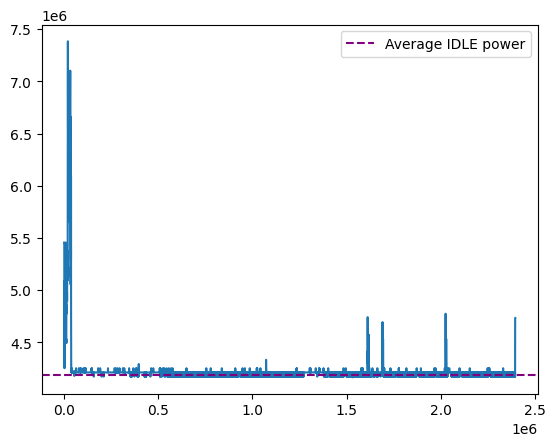

In [94]:
plt.plot([power for (timestamp, power) in resnet18_power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
plt.legend()

In [8]:
def plot_inference_cycle_power(cycle, power_data, latency_data):
    curr_cycle = latency_data[cycle]
    first_cycle_first_layer_start_time = curr_cycle[0][1]
    first_cycle_last_layer_end_time = curr_cycle[-1][2]
    next_cycle_with_delay = curr_cycle[-1][2] + timedelta(0, DELAY)
    print(f"{first_cycle_first_layer_start_time} -> {first_cycle_last_layer_end_time}")
    print(next_cycle_with_delay)
    print(f"Time taken by inference cycle {cycle}: {first_cycle_last_layer_end_time - first_cycle_first_layer_start_time}")

    i, flag = 0, False
    while True:
        timestamp = power_data[i][0]
        if timestamp >= first_cycle_first_layer_start_time:
            start_index = i
            while timestamp <= next_cycle_with_delay:
                timestamp = power_data[i][0]
                i += 1
                flag = True
            end_delay_index = i
            break
        i += 1
        if flag:
            break
    i = start_index
    timestamp = power_data[i][0]
    while timestamp <= first_cycle_last_layer_end_time:
        timestamp = power_data[i][0]
        i += 1
        flag = True
    end_index = i
    print(f"Iteration: {cycle}, Power index: {start_index} -> {end_index}")
    print(end_delay_index)

    fig = plt.figure()
    plt.plot(range(start_index, end_delay_index), [power for (timestamp, power) in power_data[start_index:end_delay_index]])
    plt.axvline(start_index, color='green', label='inference start')
    plt.axvline(end_index, color='blue', label='inference end')
    plt.axvline(end_delay_index, color='purple', label='delay end')
    plt.legend()
    plt.show()
    print("Power values:")
    print(f"Inference start: {power_data[start_index][1]}")
    print(f"Inference end: {power_data[end_index][1]}")
    print(f"Delay end: {power_data[end_delay_index][1]}")
    print("-"*100)

### Observations

There is a lot to unpack here from all the plots below.

Before that we will talk about `plot_inference_cycle_power` function, how it works and what it is doing.
- For a input inference cycle, the function finds the start index in the power logs data where `power_log_time >= first_layer_start_time`
- We iterate this loop until `power_log_time <= last_layer_end_time + 1 (sec)`. The index where loop finishes includes the time taken for the inference (start of first layer to end of last layer) and the delay of 1 second.
- Similarly, we find a power index corresponding to end time of last layer.

We have 3 indexes in power data for a given inference cycle
1. When the first layer for the network started
2. When the last layer for the network ended
3. When the delay of 1 second ended after the inference

Using these 3 values, we plot a line plot showing these 3 points as vertical lines.

#### Result

Let's take a look at **first iteration**,
1. The start and end vertical lines for the inference are so close to each other.
2. The power when inference started and ended was `6099456.0`.
3. Then there is a delay of 1 second and power starts to decrease gradually.
4. The power at the end of 1 second delay was `4373952.0`

**Second iteration**
1. Similarly, the start and end vertical lines are overlapping.
2. The power seems to dissipating continuning the same trend from the first iteration.
3. The power at the start of inference was `4373952.0` and at the end of inference it decreased to `4414080.0`.
4. The power at the end of 1 second delay was `4213440.0`. This is an interesting value. We will come back to it later.

**Third iteration**
1. During the inference, power increased from `4213440.0` to `4253568.0`.
2. After the inference there is a 1 second delay, the power comes back down to the same value it started with `4213440.0`.
3. The same power value during the delay of second and third iteration is observed.

**Fourth iteration**
1. The power is constant `4213440.0` for the entire inference and during the delay.
2. Same power value as previous two iteration is observed. Interestingly, here the entire inference takes same value of power to that of power consumed in the delay between the inferences.

**The rest of the iterations have pretty much the same power profile as the fourth iteration.**


### Different power patterns

- In **iteration 6**, the delay power rises from `4213440.0` to `4220160.0`
- In **iteration 7**, the delay power returns back to `4213440.0`

There are some interesting power consumption patterns going on when the delay is ocurring

- In **fifth iteration**, after the inference completes and delay of 1 second starts, the power increases and decreases back to same value of `4213440.0`.
- In **iteration 9**, there is spike in power in between the delay. Similar observation for **iteration 12 and 14**.

For **iteration 100 to 200**

- For almost all the inference cycles, the power profile is similar to iteration 4, everywhere the power value is `4213440.0`.
- There is spike during inference for **iteration 141**, where inference starts as`4213440.0`, ends at `4253568.0` and during the delay it drops back to `4213440.0`.
- Similar power profile to above is observed for **iteration 183** and **iteration 197** with exactly same power values.


2025-01-15 10:57:37.321153 -> 2025-01-15 10:57:37.322113
2025-01-15 10:57:38.322113
Time taken by inference cycle 0: 0:00:00.000960
Iteration: 0, Power index: 35851 -> 35853
36636


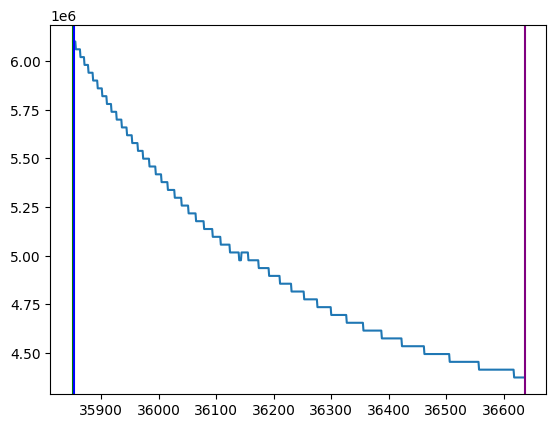

Power values:
Inference start: 6099456.0
Inference end: 6099456.0
Delay end: 4373952.0
----------------------------------------------------------------------------------------------------
2025-01-15 10:57:38.324884 -> 2025-01-15 10:57:38.325831
2025-01-15 10:57:39.325831
Time taken by inference cycle 1: 0:00:00.000947
Iteration: 1, Power index: 36637 -> 36639
37421


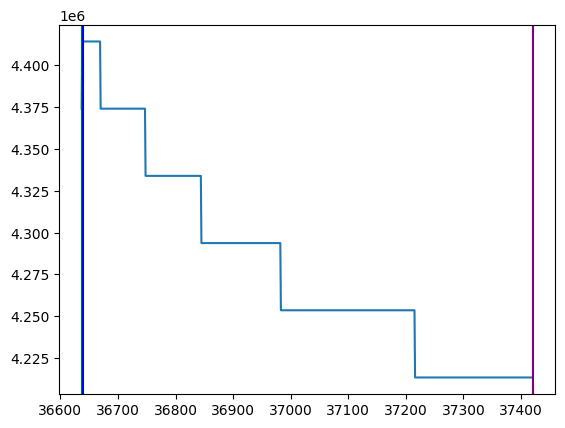

Power values:
Inference start: 4373952.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 10:57:39.328538 -> 2025-01-15 10:57:39.329497
2025-01-15 10:57:40.329497
Time taken by inference cycle 2: 0:00:00.000959
Iteration: 2, Power index: 37422 -> 37424
38208


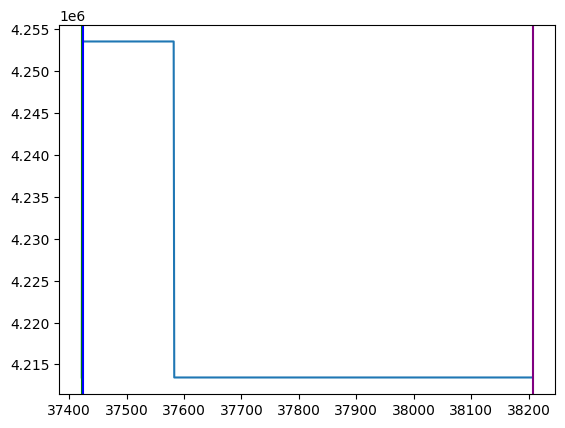

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 10:57:40.332156 -> 2025-01-15 10:57:40.333147
2025-01-15 10:57:41.333147
Time taken by inference cycle 3: 0:00:00.000991
Iteration: 3, Power index: 38209 -> 38211
38995


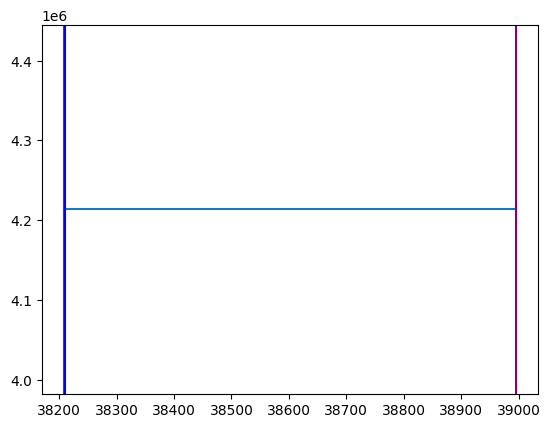

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 10:57:41.335847 -> 2025-01-15 10:57:41.336826
2025-01-15 10:57:42.336826
Time taken by inference cycle 4: 0:00:00.000979
Iteration: 4, Power index: 38996 -> 38998
39781


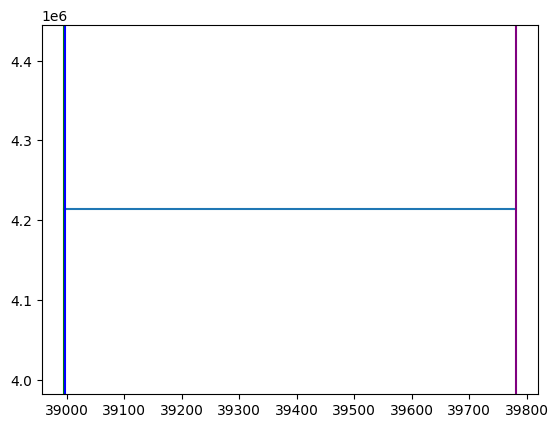

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 10:57:42.339532 -> 2025-01-15 10:57:42.340507
2025-01-15 10:57:43.340507
Time taken by inference cycle 5: 0:00:00.000975
Iteration: 5, Power index: 39782 -> 39784
40567


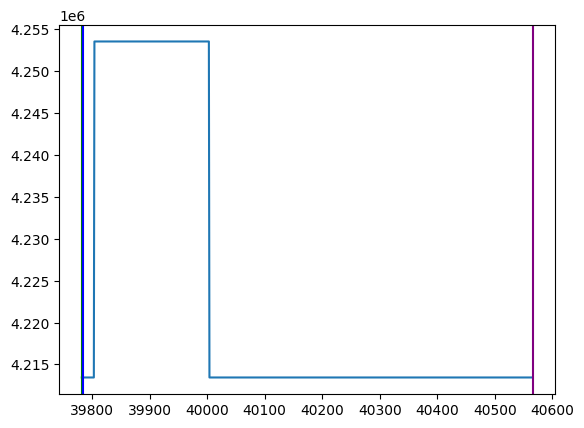

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 10:57:43.343228 -> 2025-01-15 10:57:43.344204
2025-01-15 10:57:44.344204
Time taken by inference cycle 6: 0:00:00.000976
Iteration: 6, Power index: 40568 -> 40570
41353


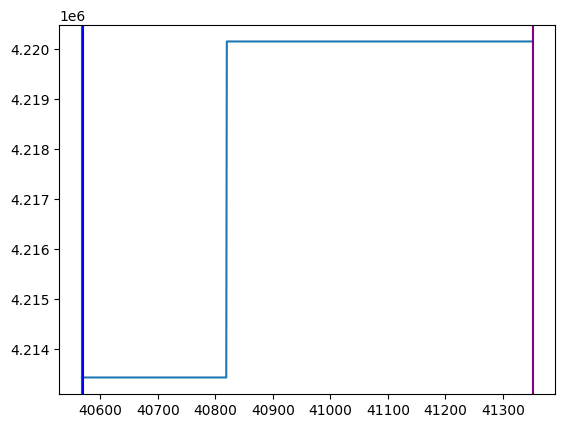

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4220160.0
----------------------------------------------------------------------------------------------------
2025-01-15 10:57:44.346806 -> 2025-01-15 10:57:44.347770
2025-01-15 10:57:45.347770
Time taken by inference cycle 7: 0:00:00.000964
Iteration: 7, Power index: 41354 -> 41356
42139


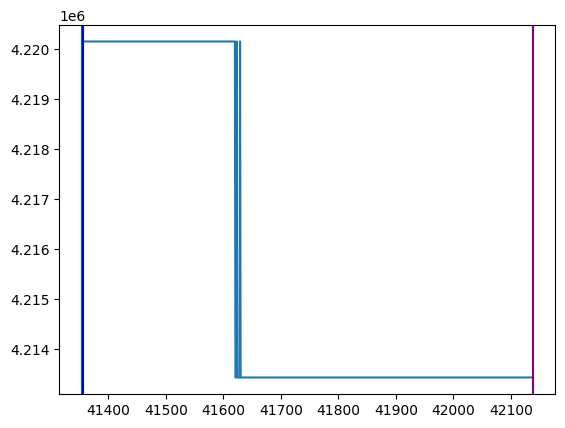

Power values:
Inference start: 4220160.0
Inference end: 4220160.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 10:57:45.350542 -> 2025-01-15 10:57:45.351490
2025-01-15 10:57:46.351490
Time taken by inference cycle 8: 0:00:00.000948
Iteration: 8, Power index: 42140 -> 42140
42924


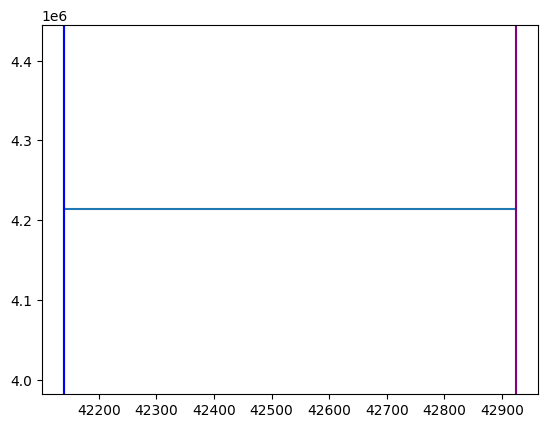

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 10:57:46.354139 -> 2025-01-15 10:57:46.355125
2025-01-15 10:57:47.355125
Time taken by inference cycle 9: 0:00:00.000986
Iteration: 9, Power index: 42926 -> 42926
43710


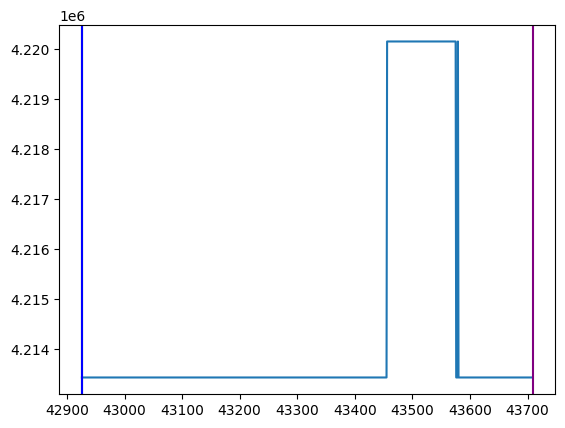

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 10:57:47.357720 -> 2025-01-15 10:57:47.358711
2025-01-15 10:57:48.358711
Time taken by inference cycle 10: 0:00:00.000991
Iteration: 10, Power index: 43711 -> 43713
44496


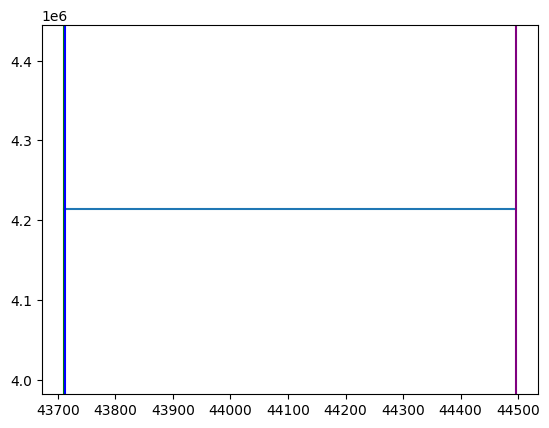

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 10:57:48.361196 -> 2025-01-15 10:57:48.362185
2025-01-15 10:57:49.362185
Time taken by inference cycle 11: 0:00:00.000989
Iteration: 11, Power index: 44497 -> 44499
45282


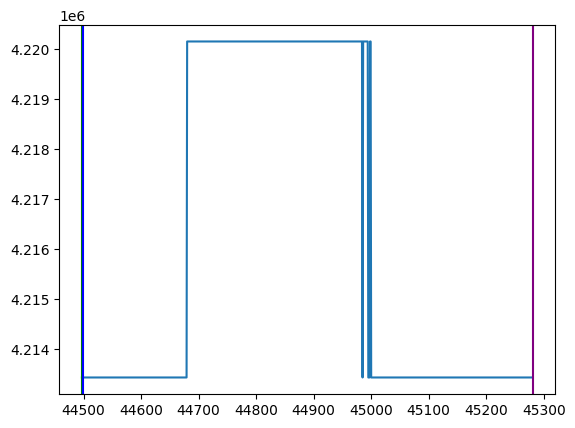

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 10:57:49.364009 -> 2025-01-15 10:57:49.365001
2025-01-15 10:57:50.365001
Time taken by inference cycle 12: 0:00:00.000992
Iteration: 12, Power index: 45282 -> 45284
46067


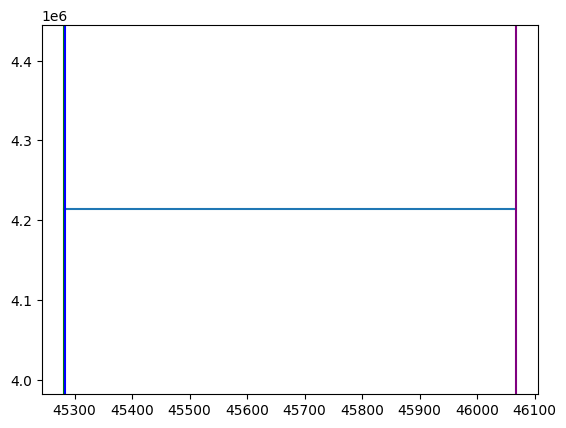

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 10:57:50.367617 -> 2025-01-15 10:57:50.368593
2025-01-15 10:57:51.368593
Time taken by inference cycle 13: 0:00:00.000976
Iteration: 13, Power index: 46068 -> 46070
46853


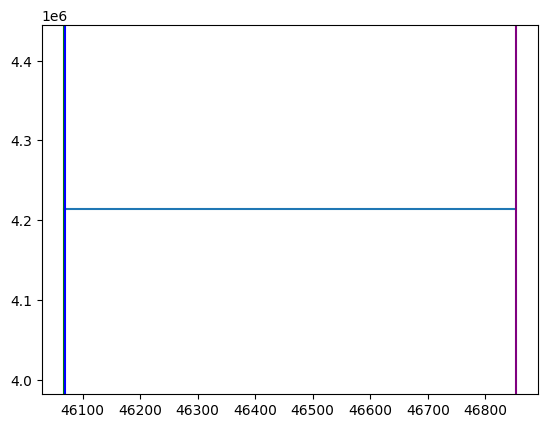

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 10:57:51.371224 -> 2025-01-15 10:57:51.372202
2025-01-15 10:57:52.372202
Time taken by inference cycle 14: 0:00:00.000978
Iteration: 14, Power index: 46854 -> 46856
47640


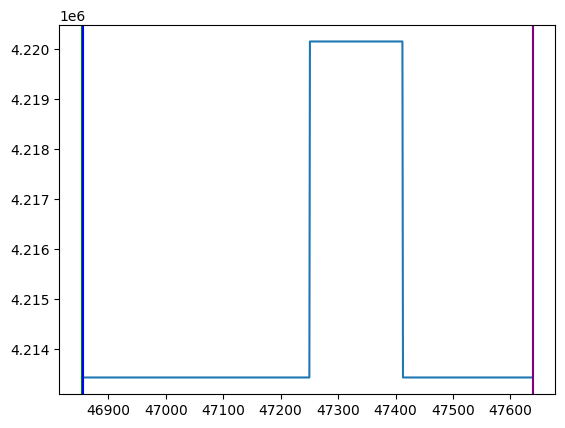

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------


In [9]:
for i in range(15):
    plot_inference_cycle_power(i, resnet18_power_data, resnet18_latency_data)

### Spikes

We see some pikes in the overall power profile above. Here we investigate which inference cycle are these coming from.

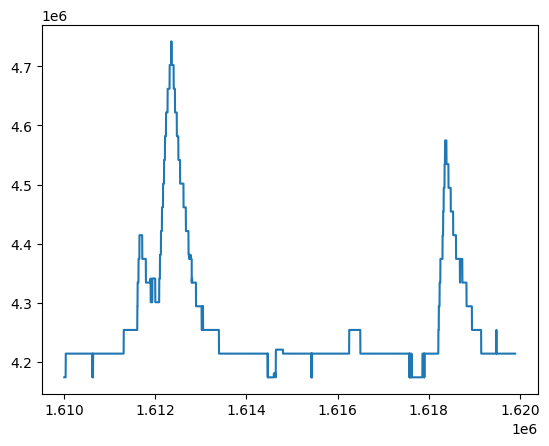

In [89]:
plt.plot(range(1610000, 1619900), [power for (timestamp, power) in resnet18_power_data[1610000:1619900]])

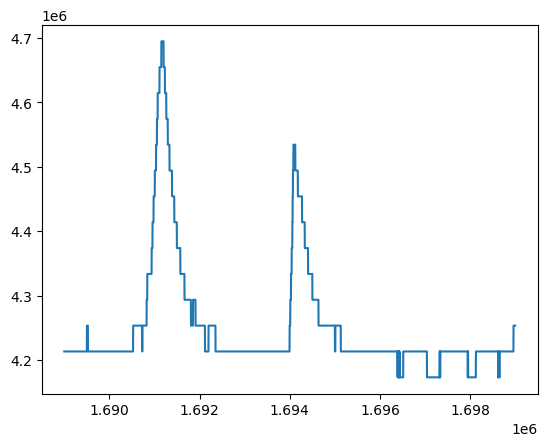

In [86]:
plt.plot(range(1689000, 1699000), [power for (timestamp, power) in resnet18_power_data[1689000:1699000]])

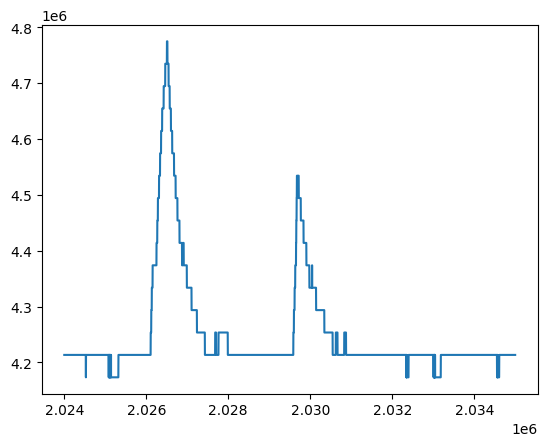

In [103]:
plt.plot(range(2024000, 2035000), [power for (timestamp, power) in resnet18_power_data[2024000:2035000]])

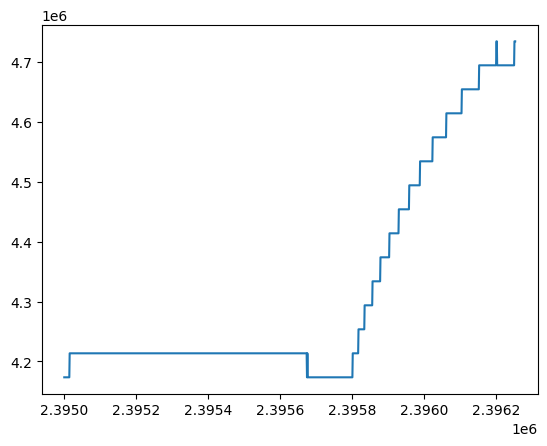

In [107]:
plt.plot(range(2395000, 2396253), [power for (timestamp, power) in resnet18_power_data[2395000:2396253]])

## Questions

The pattern that we observe is there is lot of power consumption when TensorRT model is being built by TorchTensorRT library. Once the inference starts, this power consumption starts decreasing and remains stable *largely* at `4213440.0` value both during the inference and between the delay in the consecutive inference calls.

From above investigation, here are few questions that arise/left unanswered

* Why are there *sometimes* power spikes in the delay between inference calls? There are couple of instances where power jumps from `4213440.0` to some higher value and climbs down back to `4213440.0` before the delay ends. 
* There are couple of instances where the power consumption jumps from steady `4213440.0` to `4700000` shown in the Spikes section above. Why do these inference cycles (although only handful) consume large power?

## Resnet34

In this section, we will analyse the power consumption of Resnet34 model. We will look at how the power is consumed for each inference cycle.

We add a delay between inference cycle to distinguish between consecutive inference cycles.

Resnet34 (42) has 61% more layers compared to Resnet18 (26).

In [108]:
model_name = 'resnet34'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
resnet34_power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
resnet34_latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:00<00:00, 70.37it/s]


In [109]:
print(f"Number of power entries for {model_name}: {len(resnet34_power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(resnet34_latency_data[0])}")
layer = list(data.keys())[0]
print(f"Number of latency entries for each layer: {len(resnet34_latency_data)}")

Number of power entries for resnet34: 2395346
Number of TensorRT layers in resnet34: 42
Number of latency entries for each layer: 3000


### Power Analysis

This is what the power plot looks like for 3000 inference cycles.

We see the power spikes in between 0.0 to 0.1 (1e6). This is where TorchTensorRT creates a TensorRT engine from PyTorch model. This part of the plot will be investigated as part of different notebook.

In this notebook, we will look at the plot after 0.1.

The plot looks less "spikey" compared to resnet18.

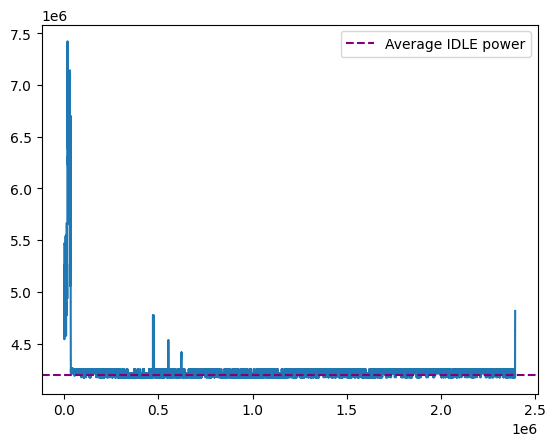

In [110]:
plt.plot([power for (timestamp, power) in resnet34_power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
plt.legend()

### Observations

The methodology to get the index corresponding to the power log is similar to Resnet18.

Here we will look into the individual iterations.

#### Result

Let's take a look at **first iteration**,
1. The start and end vertical lines for the inference are so close to each other.
2. The power when inference started and ended was `6661248.0`. **Much higher than resnet18**
3. Then there is a delay of 1 second and power starts to decrease gradually.
4. The power at the end of 1 second delay was `4454208.0`

**Second iteration**
1. The inference start and end power values were `4454208.0`.
2. Interestingly, the delay value of **power reaches to the same value of delay** we observed in the resnet18 model `4213440.0`.

The pattern observed in the subsequent iterations
1. The inference start starts with higher power (*most times similar*) than the power consumed in delay `4213440.0`.
2. The inference end with a higher power value than inference start `4253568.0`, `4260352.0`.
3. Finally, the power consumed in delay brings the power value back to `4213440.0`.

> **The power does not stay constant as observed in resnet18 during and after inference.**

> **The power increases from the start of inference to the end of inference and gradually brought down to `4213440.0` in the 1 second delay sleep interval.**

2025-01-15 11:48:50.744358 -> 2025-01-15 11:48:50.745953
2025-01-15 11:48:51.745953
Time taken by inference cycle 0: 0:00:00.001595
Iteration: 0, Power index: 33700 -> 33702
34489


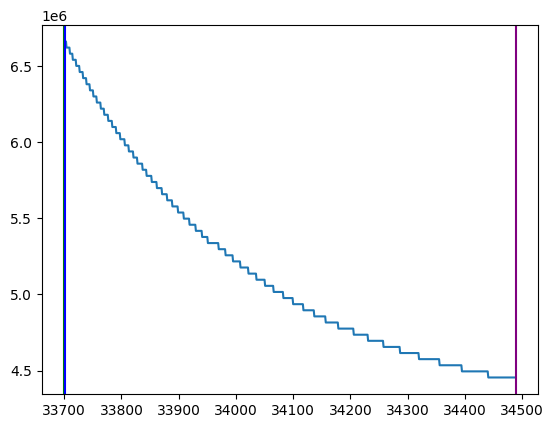

Power values:
Inference start: 6661248.0
Inference end: 6661248.0
Delay end: 4454208.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:48:51.748873 -> 2025-01-15 11:48:51.750534
2025-01-15 11:48:52.750534
Time taken by inference cycle 1: 0:00:00.001661
Iteration: 1, Power index: 34490 -> 34492
35279


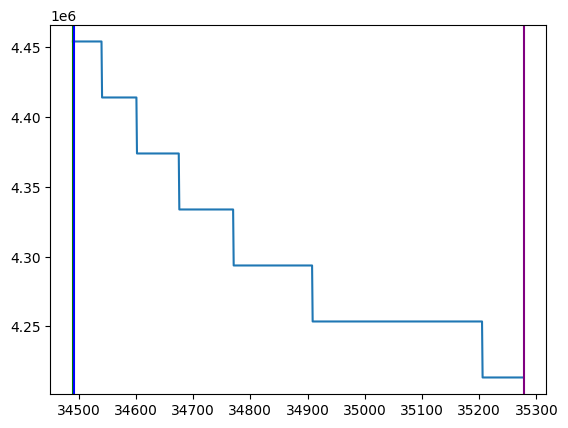

Power values:
Inference start: 4454208.0
Inference end: 4454208.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:48:52.753590 -> 2025-01-15 11:48:52.755297
2025-01-15 11:48:53.755297
Time taken by inference cycle 2: 0:00:00.001707
Iteration: 2, Power index: 35280 -> 35283
36069


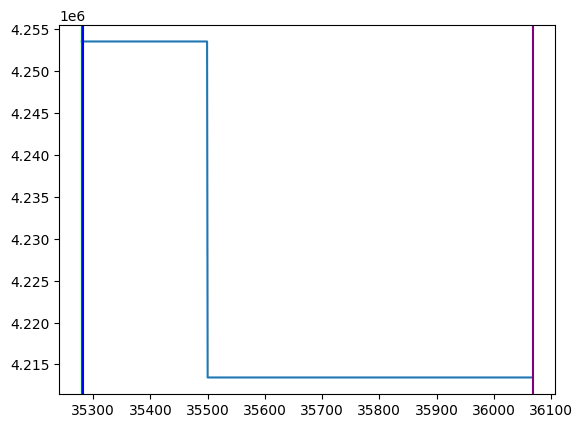

Power values:
Inference start: 4253568.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:48:53.758251 -> 2025-01-15 11:48:53.759969
2025-01-15 11:48:54.759969
Time taken by inference cycle 3: 0:00:00.001718
Iteration: 3, Power index: 36071 -> 36073
36860


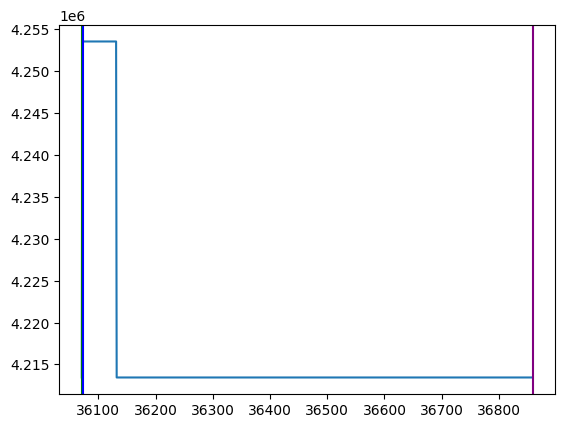

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:48:54.762888 -> 2025-01-15 11:48:54.764594
2025-01-15 11:48:55.764594
Time taken by inference cycle 4: 0:00:00.001706
Iteration: 4, Power index: 36861 -> 36864
37650


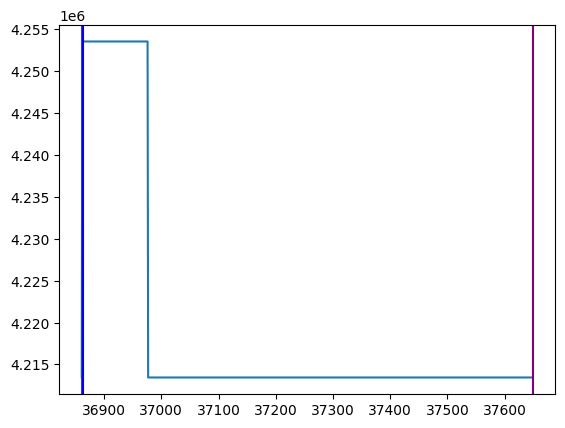

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:48:55.767518 -> 2025-01-15 11:48:55.769223
2025-01-15 11:48:56.769223
Time taken by inference cycle 5: 0:00:00.001705
Iteration: 5, Power index: 37651 -> 37654
38440


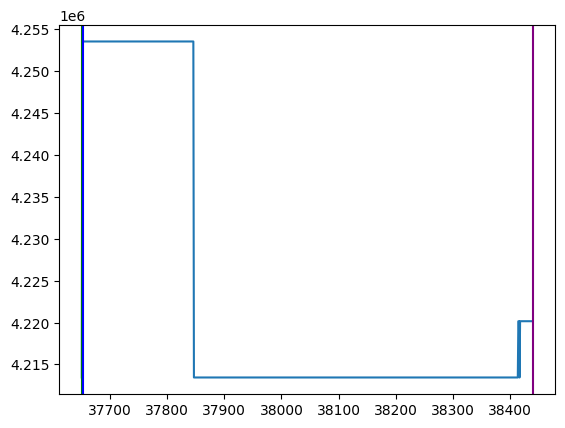

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4220160.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:48:56.772144 -> 2025-01-15 11:48:56.773857
2025-01-15 11:48:57.773857
Time taken by inference cycle 6: 0:00:00.001713
Iteration: 6, Power index: 38442 -> 38444
39230


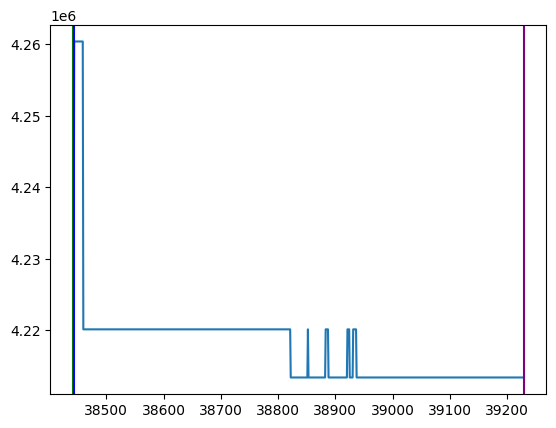

Power values:
Inference start: 4220160.0
Inference end: 4260352.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:48:57.776442 -> 2025-01-15 11:48:57.778117
2025-01-15 11:48:58.778117
Time taken by inference cycle 7: 0:00:00.001675
Iteration: 7, Power index: 39231 -> 39234
40020


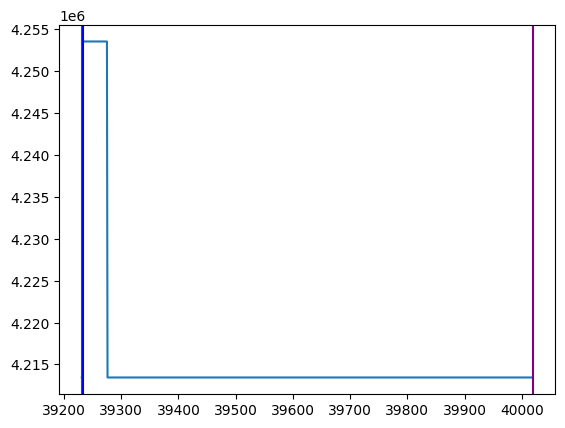

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:48:58.780508 -> 2025-01-15 11:48:58.782125
2025-01-15 11:48:59.782125
Time taken by inference cycle 8: 0:00:00.001617
Iteration: 8, Power index: 40021 -> 40023
40810


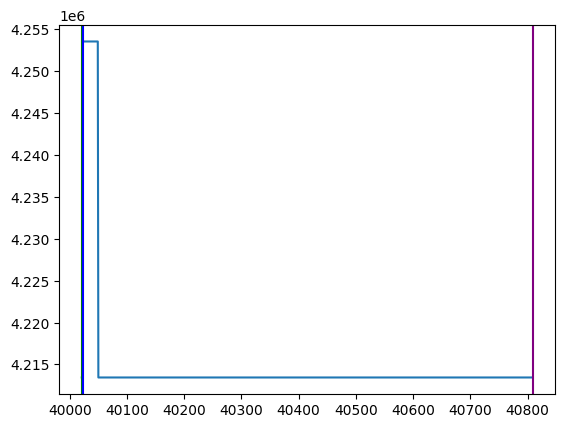

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:48:59.784447 -> 2025-01-15 11:48:59.786107
2025-01-15 11:49:00.786107
Time taken by inference cycle 9: 0:00:00.001660
Iteration: 9, Power index: 40810 -> 40813
41599


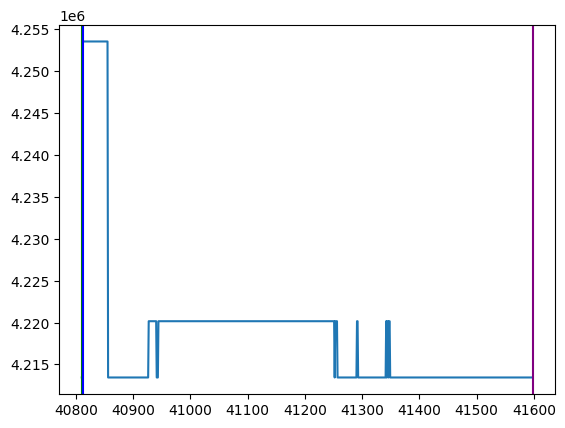

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:49:00.788385 -> 2025-01-15 11:49:00.790033
2025-01-15 11:49:01.790033
Time taken by inference cycle 10: 0:00:00.001648
Iteration: 10, Power index: 41599 -> 41602
42388


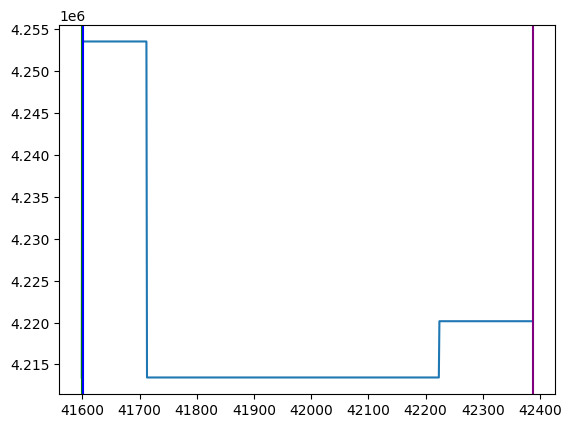

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4220160.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:49:01.792495 -> 2025-01-15 11:49:01.794128
2025-01-15 11:49:02.794128
Time taken by inference cycle 11: 0:00:00.001633
Iteration: 11, Power index: 42389 -> 42391
43177


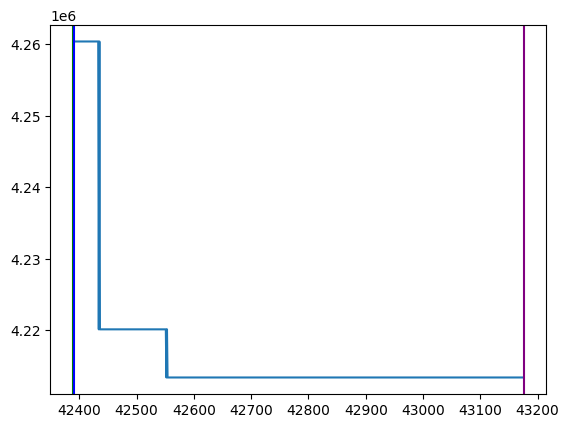

Power values:
Inference start: 4220160.0
Inference end: 4260352.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:49:02.796461 -> 2025-01-15 11:49:02.798098
2025-01-15 11:49:03.798098
Time taken by inference cycle 12: 0:00:00.001637
Iteration: 12, Power index: 43178 -> 43180
43967


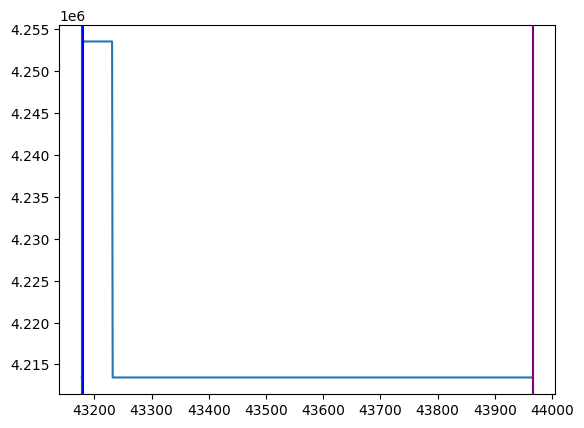

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:49:03.800249 -> 2025-01-15 11:49:03.801970
2025-01-15 11:49:04.801970
Time taken by inference cycle 13: 0:00:00.001721
Iteration: 13, Power index: 43967 -> 43969
44756


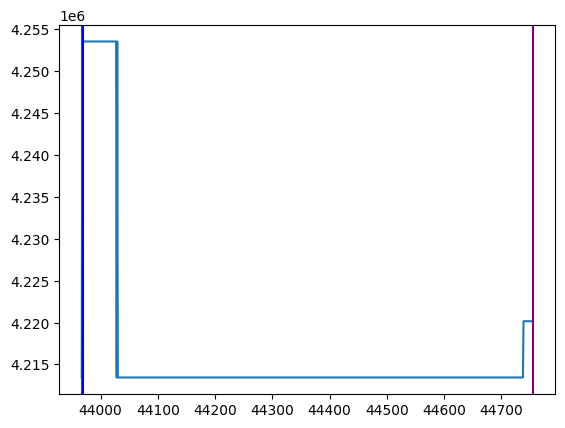

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4220160.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:49:04.804772 -> 2025-01-15 11:49:04.806490
2025-01-15 11:49:05.806490
Time taken by inference cycle 14: 0:00:00.001718
Iteration: 14, Power index: 44757 -> 44759
45545


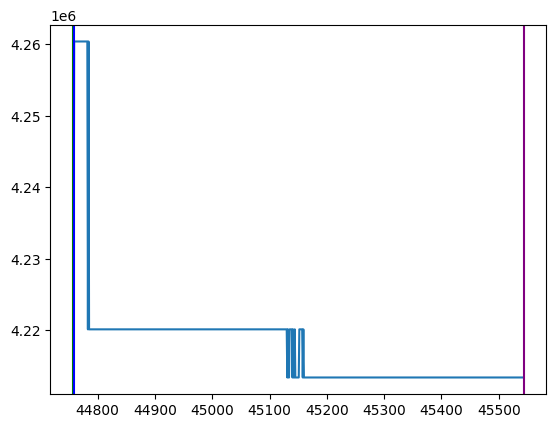

Power values:
Inference start: 4220160.0
Inference end: 4260352.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------


In [111]:
for i in range(15):
    plot_inference_cycle_power(i, resnet34_power_data, resnet34_latency_data)

2025-01-15 11:52:11.645997 -> 2025-01-15 11:52:11.647717
2025-01-15 11:52:12.647717
Time taken by inference cycle 200: 0:00:00.001720
Iteration: 200, Power index: 191364 -> 191366
192148


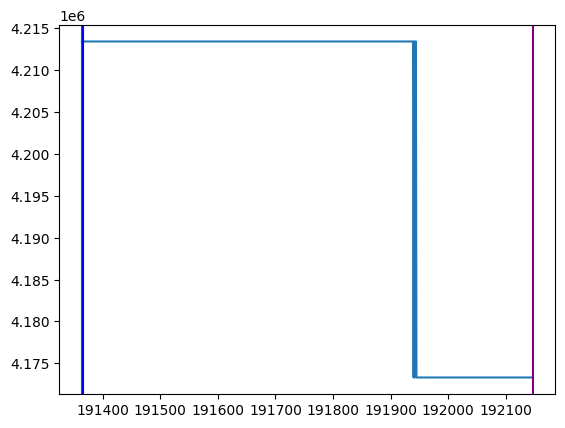

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:12.650862 -> 2025-01-15 11:52:12.652508
2025-01-15 11:52:13.652508
Time taken by inference cycle 201: 0:00:00.001646
Iteration: 201, Power index: 192150 -> 192152
192935


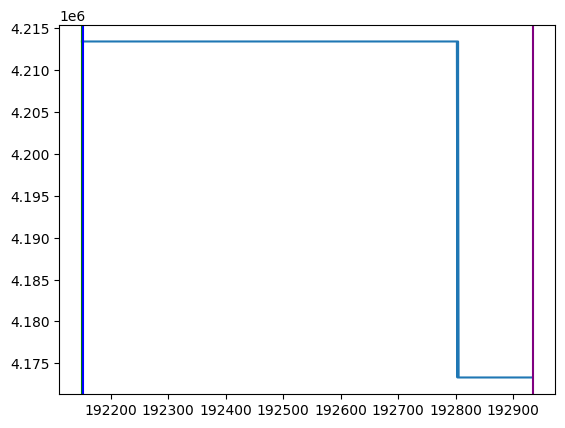

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:13.655564 -> 2025-01-15 11:52:13.657269
2025-01-15 11:52:14.657269
Time taken by inference cycle 202: 0:00:00.001705
Iteration: 202, Power index: 192936 -> 192939
193721


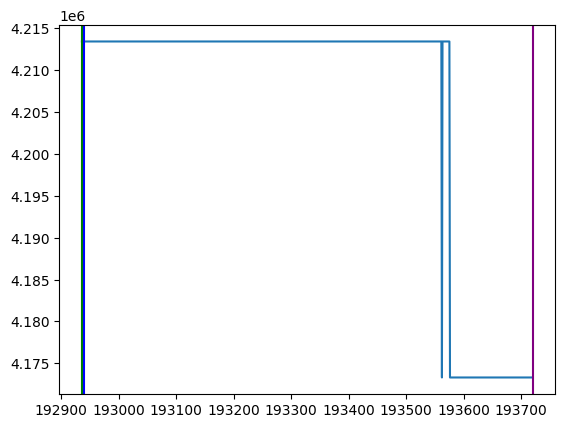

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:14.660317 -> 2025-01-15 11:52:14.662032
2025-01-15 11:52:15.662032
Time taken by inference cycle 203: 0:00:00.001715
Iteration: 203, Power index: 193722 -> 193725
194507


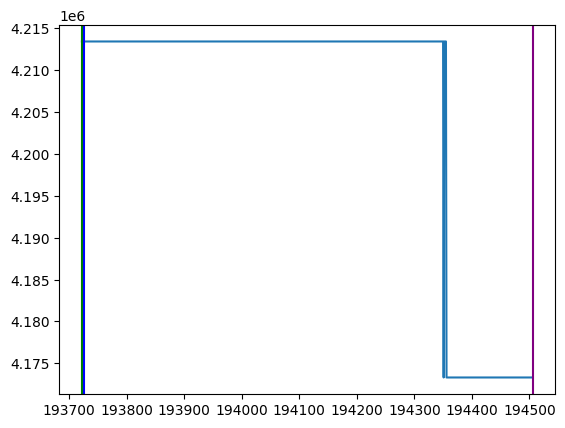

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:15.664389 -> 2025-01-15 11:52:15.666101
2025-01-15 11:52:16.666101
Time taken by inference cycle 204: 0:00:00.001712
Iteration: 204, Power index: 194508 -> 194510
195293


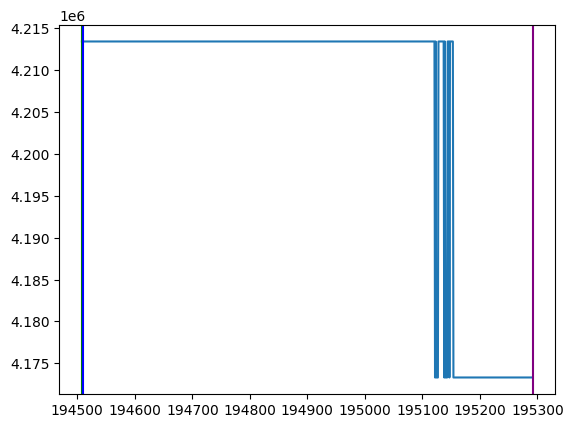

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:16.668377 -> 2025-01-15 11:52:16.670084
2025-01-15 11:52:17.670084
Time taken by inference cycle 205: 0:00:00.001707
Iteration: 205, Power index: 195293 -> 195296
196078


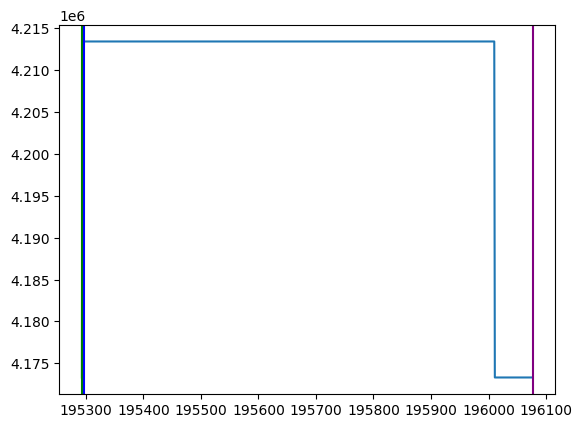

Power values:
Inference start: 4173312.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:17.672409 -> 2025-01-15 11:52:17.674117
2025-01-15 11:52:18.674117
Time taken by inference cycle 206: 0:00:00.001708
Iteration: 206, Power index: 196079 -> 196081
196864


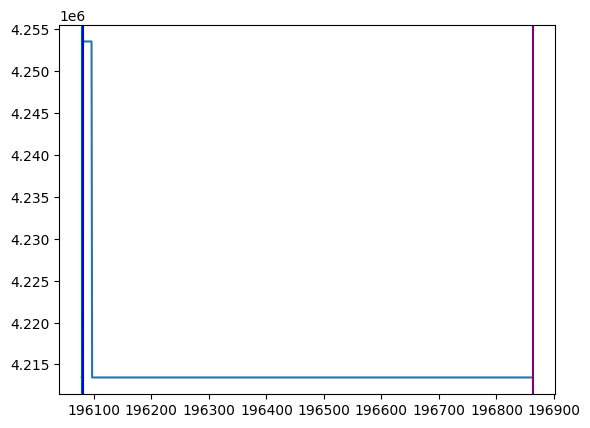

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:18.676418 -> 2025-01-15 11:52:18.678117
2025-01-15 11:52:19.678117
Time taken by inference cycle 207: 0:00:00.001699
Iteration: 207, Power index: 196865 -> 196867
197649


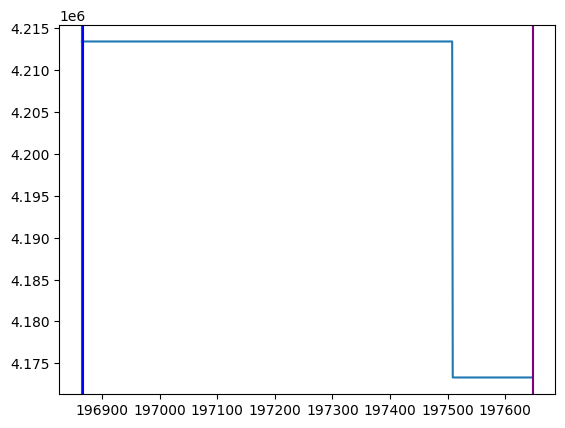

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:19.680390 -> 2025-01-15 11:52:19.682091
2025-01-15 11:52:20.682091
Time taken by inference cycle 208: 0:00:00.001701
Iteration: 208, Power index: 197650 -> 197653
198435


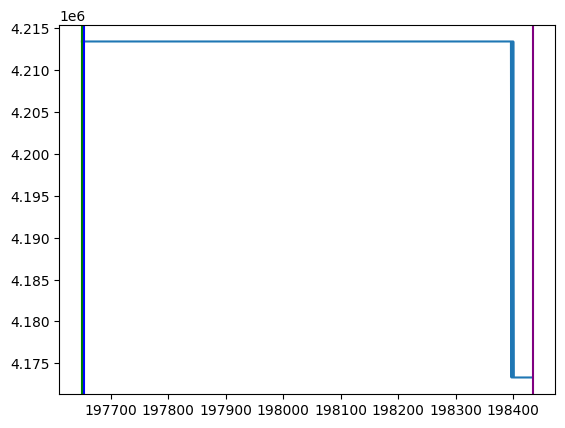

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:20.684452 -> 2025-01-15 11:52:20.686168
2025-01-15 11:52:21.686168
Time taken by inference cycle 209: 0:00:00.001716
Iteration: 209, Power index: 198436 -> 198438
199221


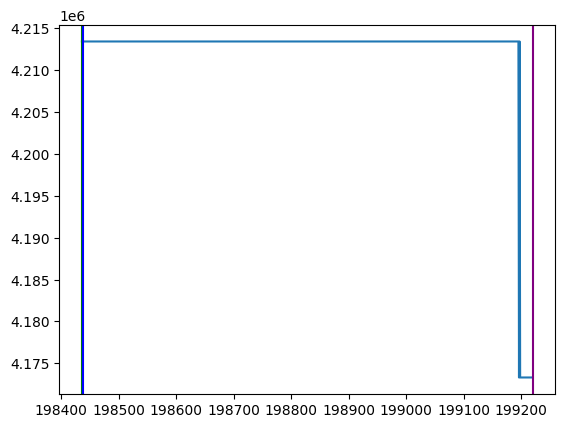

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:21.688432 -> 2025-01-15 11:52:21.690142
2025-01-15 11:52:22.690142
Time taken by inference cycle 210: 0:00:00.001710
Iteration: 210, Power index: 199222 -> 199224
200007


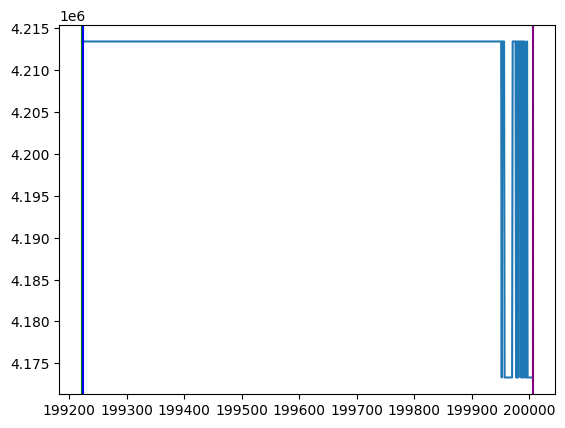

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:22.693140 -> 2025-01-15 11:52:22.694824
2025-01-15 11:52:23.694824
Time taken by inference cycle 211: 0:00:00.001684
Iteration: 211, Power index: 200008 -> 200011
200793


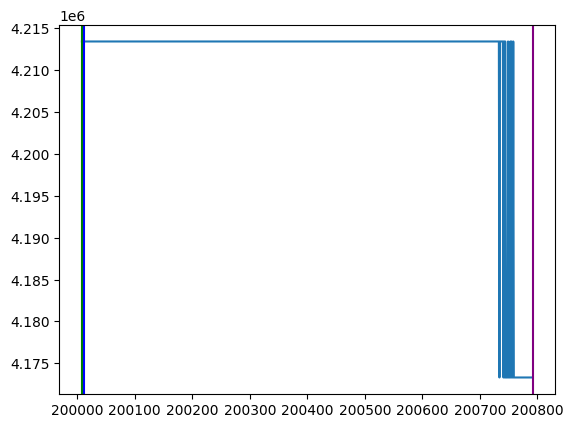

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:23.697820 -> 2025-01-15 11:52:23.699521
2025-01-15 11:52:24.699521
Time taken by inference cycle 212: 0:00:00.001701
Iteration: 212, Power index: 200794 -> 200797
201579


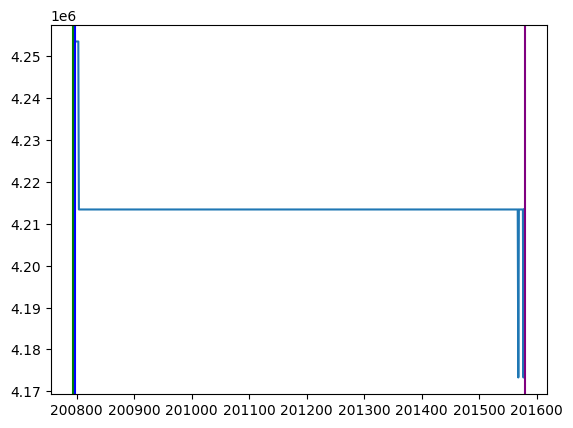

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:24.702501 -> 2025-01-15 11:52:24.704208
2025-01-15 11:52:25.704208
Time taken by inference cycle 213: 0:00:00.001707
Iteration: 213, Power index: 201580 -> 201583
202365


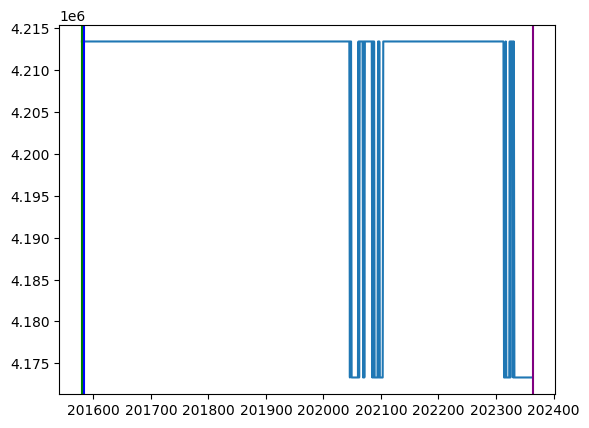

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:25.707189 -> 2025-01-15 11:52:25.708899
2025-01-15 11:52:26.708899
Time taken by inference cycle 214: 0:00:00.001710
Iteration: 214, Power index: 202367 -> 202369
203151


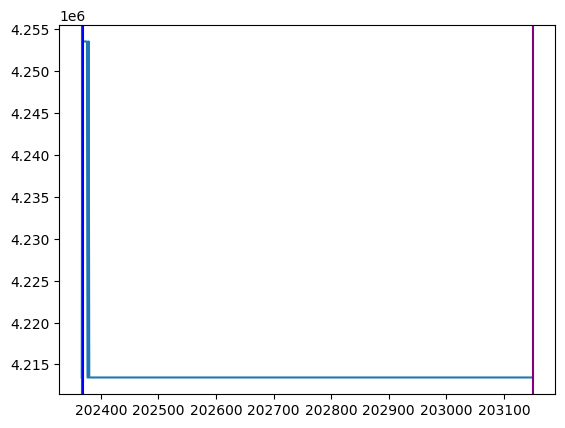

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:26.711901 -> 2025-01-15 11:52:26.713610
2025-01-15 11:52:27.713610
Time taken by inference cycle 215: 0:00:00.001709
Iteration: 215, Power index: 203153 -> 203155
203937


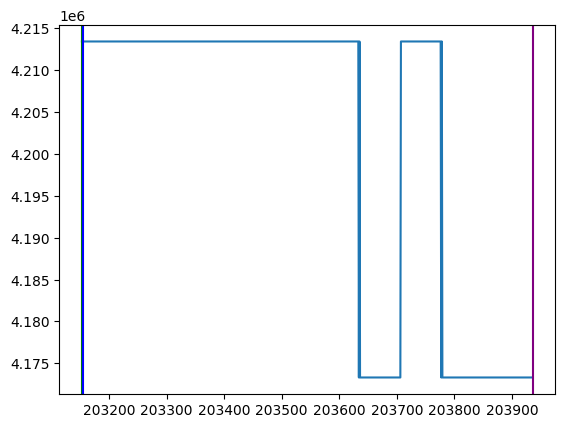

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:27.716403 -> 2025-01-15 11:52:27.718188
2025-01-15 11:52:28.718188
Time taken by inference cycle 216: 0:00:00.001785
Iteration: 216, Power index: 203938 -> 203941
204723


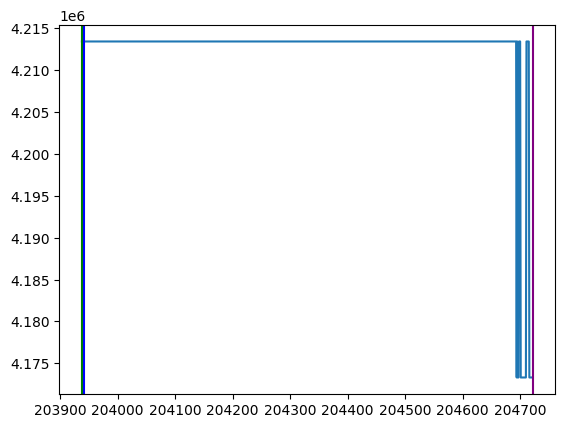

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:28.721192 -> 2025-01-15 11:52:28.722888
2025-01-15 11:52:29.722888
Time taken by inference cycle 217: 0:00:00.001696
Iteration: 217, Power index: 204725 -> 204727
205510


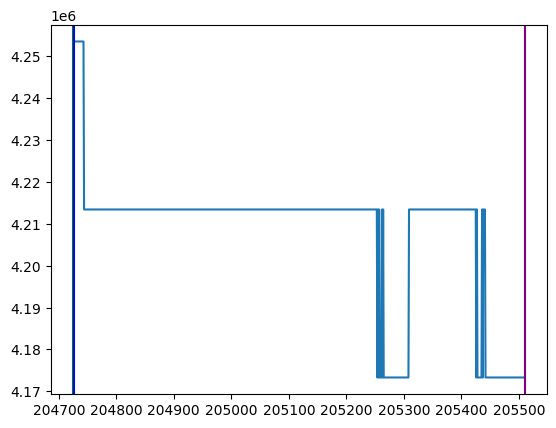

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:29.725859 -> 2025-01-15 11:52:29.727561
2025-01-15 11:52:30.727561
Time taken by inference cycle 218: 0:00:00.001702
Iteration: 218, Power index: 205511 -> 205513
206295


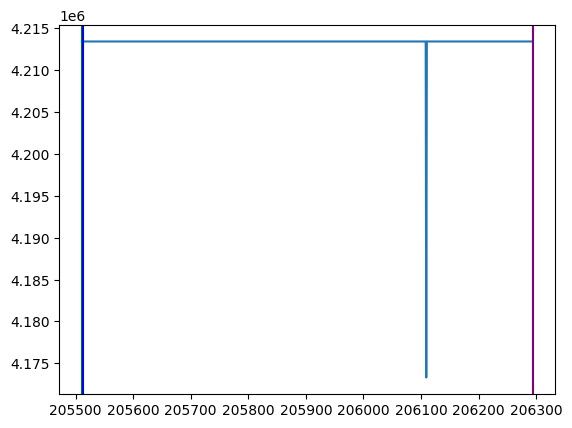

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:30.730619 -> 2025-01-15 11:52:30.732288
2025-01-15 11:52:31.732288
Time taken by inference cycle 219: 0:00:00.001669
Iteration: 219, Power index: 206297 -> 206299
207081


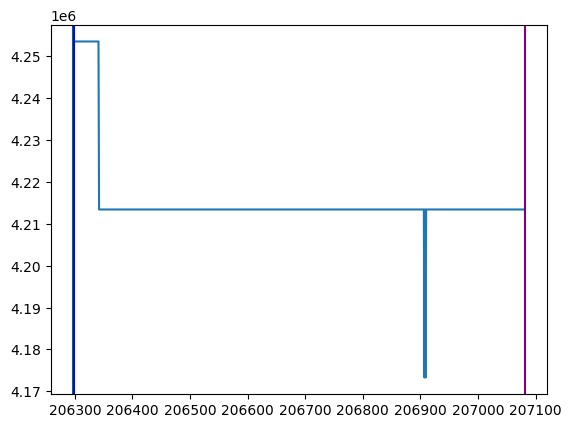

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:31.735293 -> 2025-01-15 11:52:31.737010
2025-01-15 11:52:32.737010
Time taken by inference cycle 220: 0:00:00.001717
Iteration: 220, Power index: 207082 -> 207085
207867


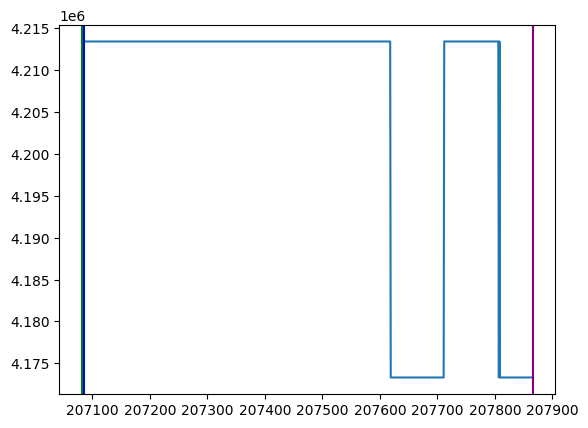

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:32.739996 -> 2025-01-15 11:52:32.741706
2025-01-15 11:52:33.741706
Time taken by inference cycle 221: 0:00:00.001710
Iteration: 221, Power index: 207868 -> 207871
208653


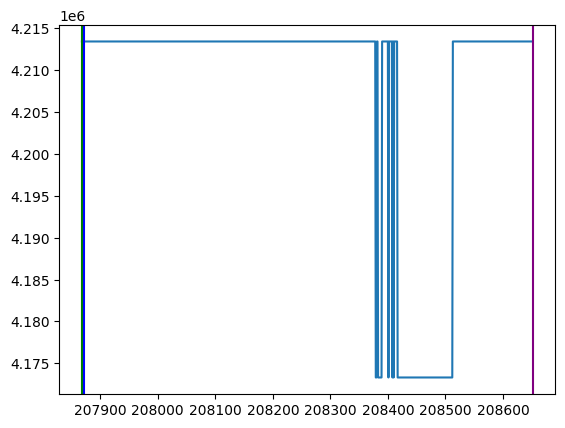

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:33.744385 -> 2025-01-15 11:52:33.746098
2025-01-15 11:52:34.746098
Time taken by inference cycle 222: 0:00:00.001713
Iteration: 222, Power index: 208654 -> 208656
209438


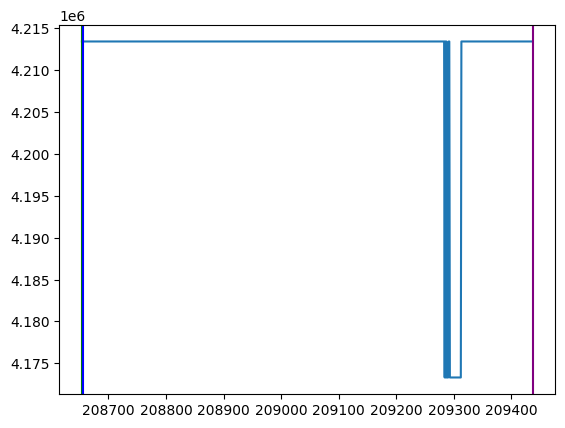

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:34.749046 -> 2025-01-15 11:52:34.750753
2025-01-15 11:52:35.750753
Time taken by inference cycle 223: 0:00:00.001707
Iteration: 223, Power index: 209439 -> 209442
210223


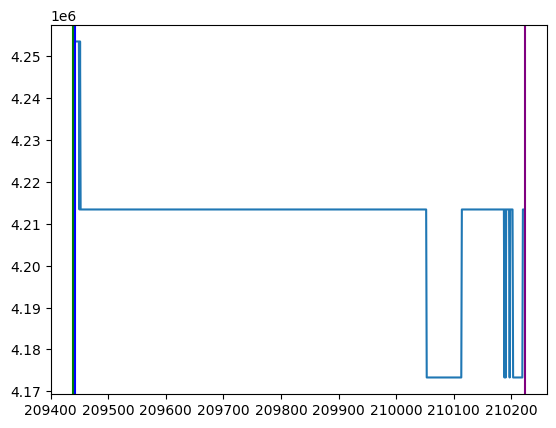

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:35.753703 -> 2025-01-15 11:52:35.755422
2025-01-15 11:52:36.755422
Time taken by inference cycle 224: 0:00:00.001719
Iteration: 224, Power index: 210224 -> 210227
211008


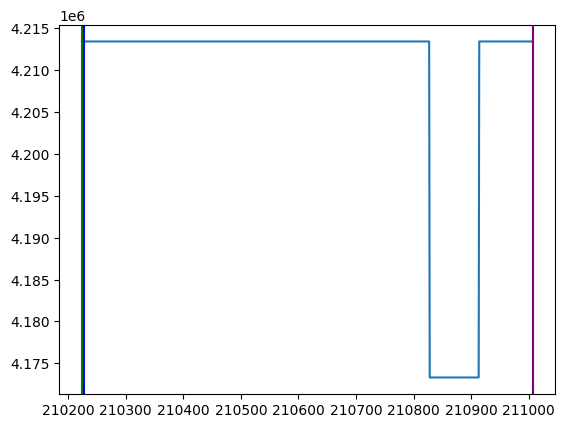

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:36.758383 -> 2025-01-15 11:52:36.760094
2025-01-15 11:52:37.760094
Time taken by inference cycle 225: 0:00:00.001711
Iteration: 225, Power index: 211009 -> 211012
211793


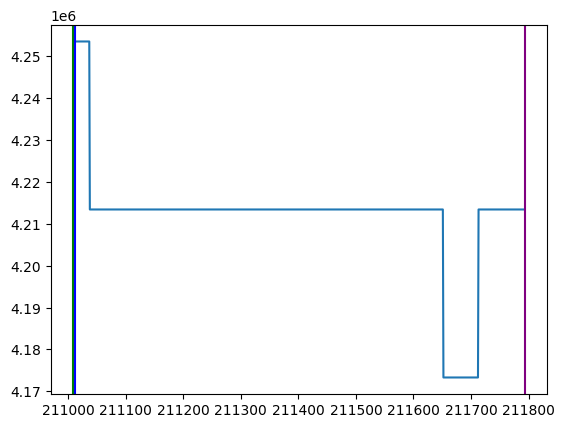

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:37.763098 -> 2025-01-15 11:52:37.764801
2025-01-15 11:52:38.764801
Time taken by inference cycle 226: 0:00:00.001703
Iteration: 226, Power index: 211794 -> 211797
212578


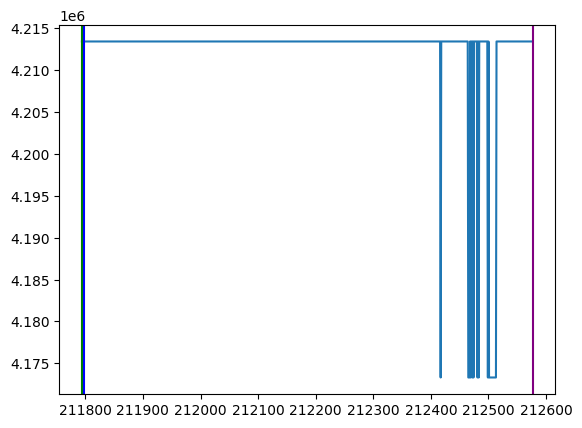

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:38.767829 -> 2025-01-15 11:52:38.769546
2025-01-15 11:52:39.769546
Time taken by inference cycle 227: 0:00:00.001717
Iteration: 227, Power index: 212580 -> 212582
213364


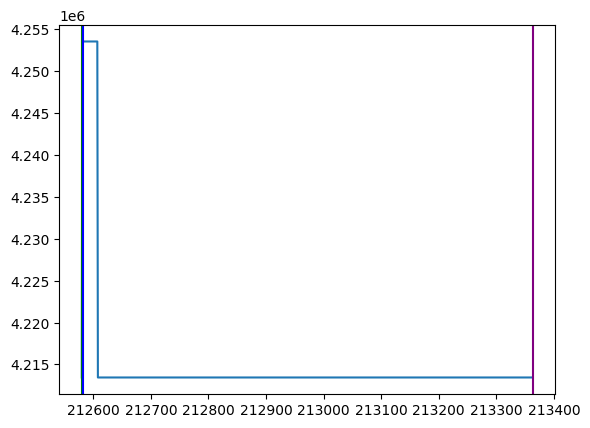

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:39.772535 -> 2025-01-15 11:52:39.774237
2025-01-15 11:52:40.774237
Time taken by inference cycle 228: 0:00:00.001702
Iteration: 228, Power index: 213366 -> 213368
214150


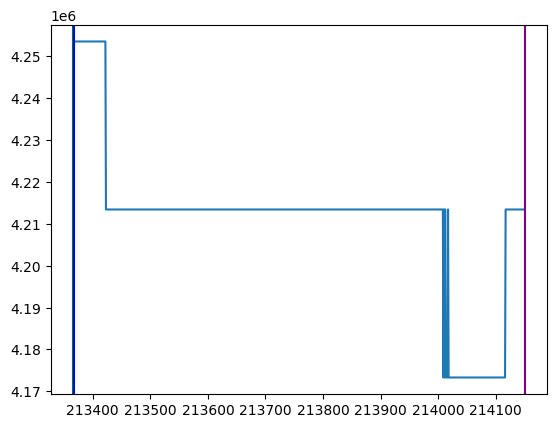

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:40.776608 -> 2025-01-15 11:52:40.778299
2025-01-15 11:52:41.778299
Time taken by inference cycle 229: 0:00:00.001691
Iteration: 229, Power index: 214151 -> 214153
214935


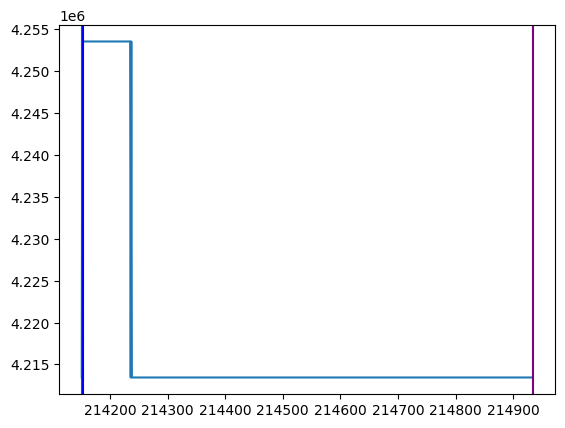

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:41.781289 -> 2025-01-15 11:52:41.783090
2025-01-15 11:52:42.783090
Time taken by inference cycle 230: 0:00:00.001801
Iteration: 230, Power index: 214936 -> 214939
215721


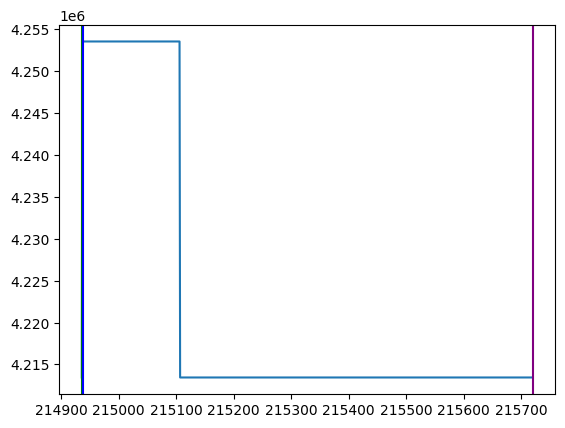

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:42.785470 -> 2025-01-15 11:52:42.787149
2025-01-15 11:52:43.787149
Time taken by inference cycle 231: 0:00:00.001679
Iteration: 231, Power index: 215722 -> 215724
216506


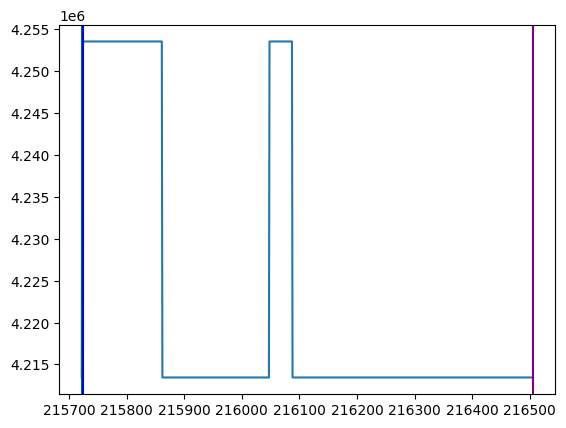

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:43.790374 -> 2025-01-15 11:52:43.792070
2025-01-15 11:52:44.792070
Time taken by inference cycle 232: 0:00:00.001696
Iteration: 232, Power index: 216508 -> 216510
217292


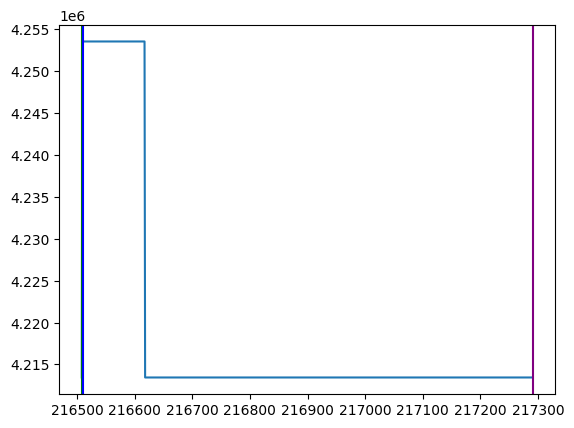

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:44.795192 -> 2025-01-15 11:52:44.796923
2025-01-15 11:52:45.796923
Time taken by inference cycle 233: 0:00:00.001731
Iteration: 233, Power index: 217294 -> 217296
218078


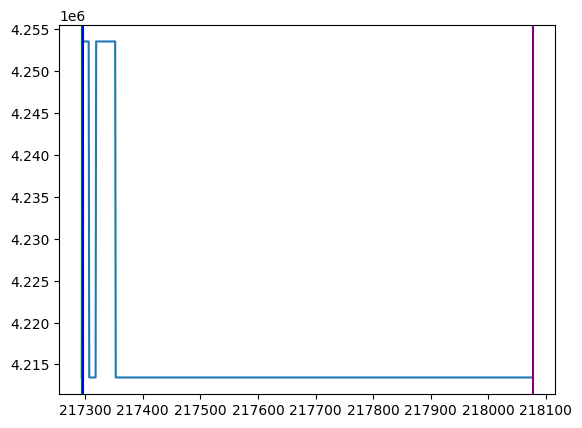

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:45.800206 -> 2025-01-15 11:52:45.801890
2025-01-15 11:52:46.801890
Time taken by inference cycle 234: 0:00:00.001684
Iteration: 234, Power index: 218080 -> 218082
218864


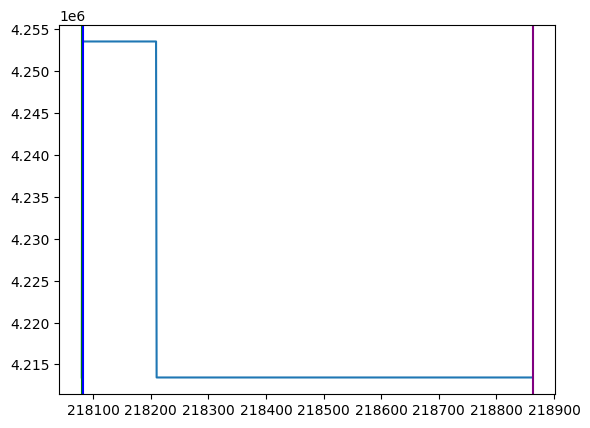

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:46.804935 -> 2025-01-15 11:52:46.806661
2025-01-15 11:52:47.806661
Time taken by inference cycle 235: 0:00:00.001726
Iteration: 235, Power index: 218866 -> 218868
219650


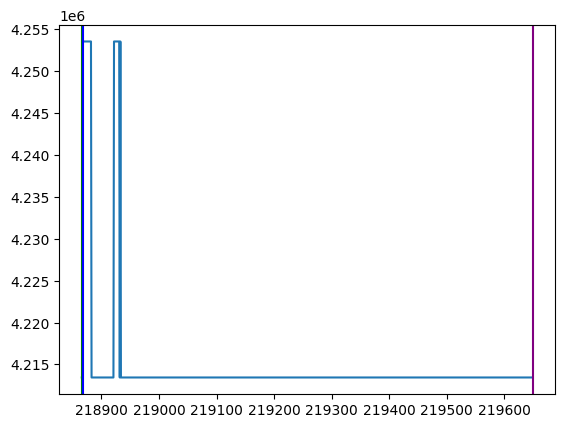

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:47.809670 -> 2025-01-15 11:52:47.811387
2025-01-15 11:52:48.811387
Time taken by inference cycle 236: 0:00:00.001717
Iteration: 236, Power index: 219651 -> 219654
220435


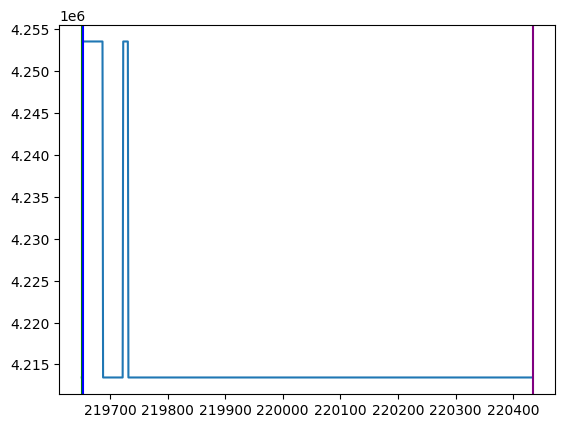

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:48.814358 -> 2025-01-15 11:52:48.816070
2025-01-15 11:52:49.816070
Time taken by inference cycle 237: 0:00:00.001712
Iteration: 237, Power index: 220437 -> 220439
221221


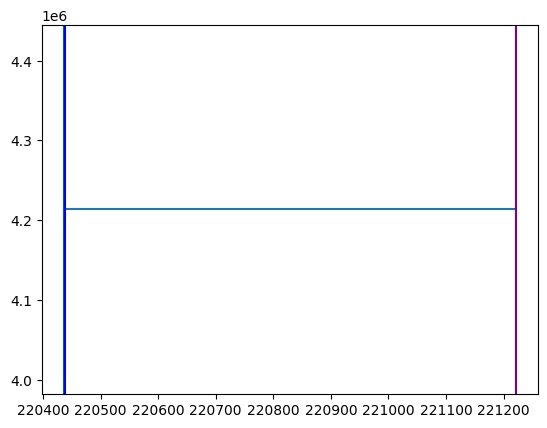

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:49.819067 -> 2025-01-15 11:52:49.820751
2025-01-15 11:52:50.820751
Time taken by inference cycle 238: 0:00:00.001684
Iteration: 238, Power index: 221222 -> 221225
222006


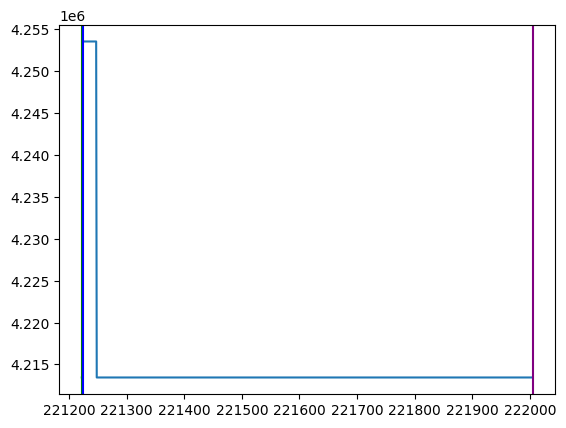

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:50.823735 -> 2025-01-15 11:52:50.825458
2025-01-15 11:52:51.825458
Time taken by inference cycle 239: 0:00:00.001723
Iteration: 239, Power index: 222008 -> 222010
222792


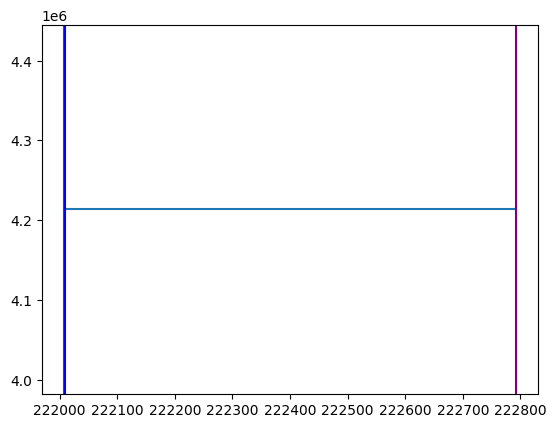

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:51.828360 -> 2025-01-15 11:52:51.830076
2025-01-15 11:52:52.830076
Time taken by inference cycle 240: 0:00:00.001716
Iteration: 240, Power index: 222793 -> 222795
223577


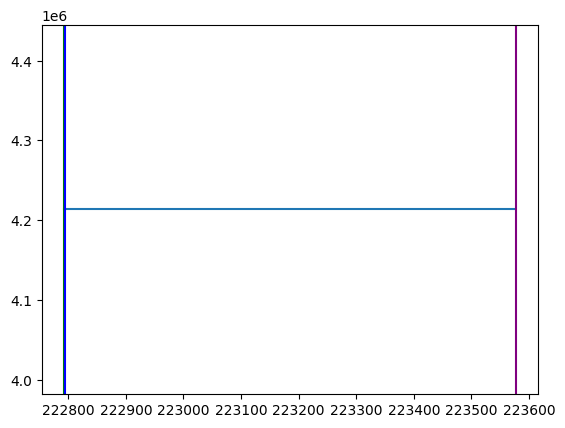

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:52.833007 -> 2025-01-15 11:52:52.834731
2025-01-15 11:52:53.834731
Time taken by inference cycle 241: 0:00:00.001724
Iteration: 241, Power index: 223579 -> 223581
224363


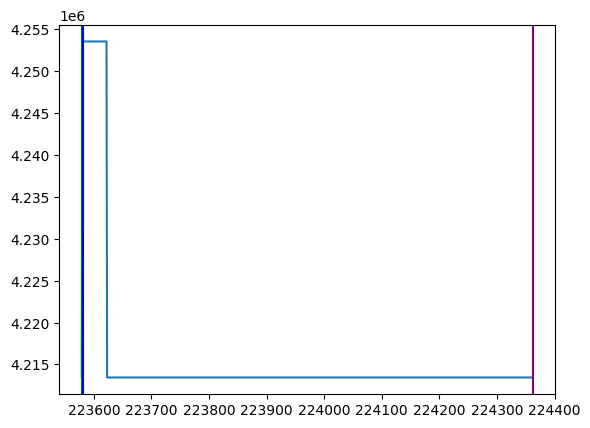

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:53.837657 -> 2025-01-15 11:52:53.839375
2025-01-15 11:52:54.839375
Time taken by inference cycle 242: 0:00:00.001718
Iteration: 242, Power index: 224364 -> 224366
225148


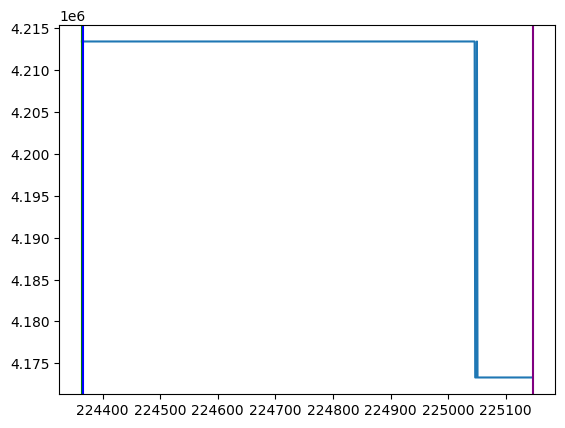

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:54.842272 -> 2025-01-15 11:52:54.843985
2025-01-15 11:52:55.843985
Time taken by inference cycle 243: 0:00:00.001713
Iteration: 243, Power index: 225149 -> 225152
225934


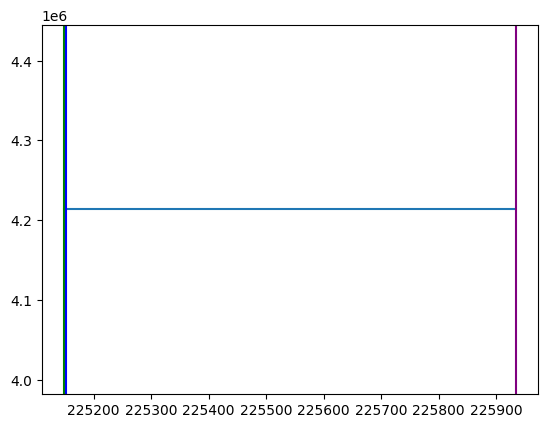

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:55.846922 -> 2025-01-15 11:52:55.848637
2025-01-15 11:52:56.848637
Time taken by inference cycle 244: 0:00:00.001715
Iteration: 244, Power index: 225935 -> 225937
226719


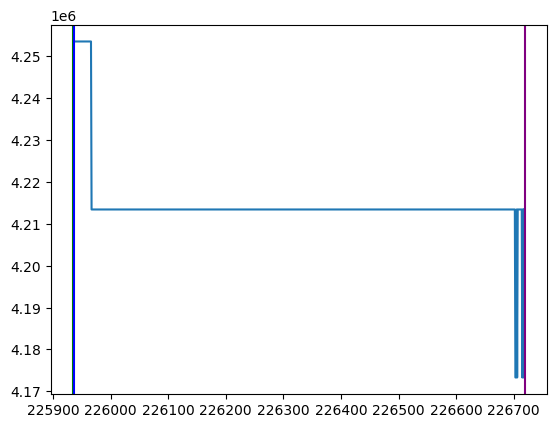

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:56.851558 -> 2025-01-15 11:52:56.853270
2025-01-15 11:52:57.853270
Time taken by inference cycle 245: 0:00:00.001712
Iteration: 245, Power index: 226720 -> 226723
227504


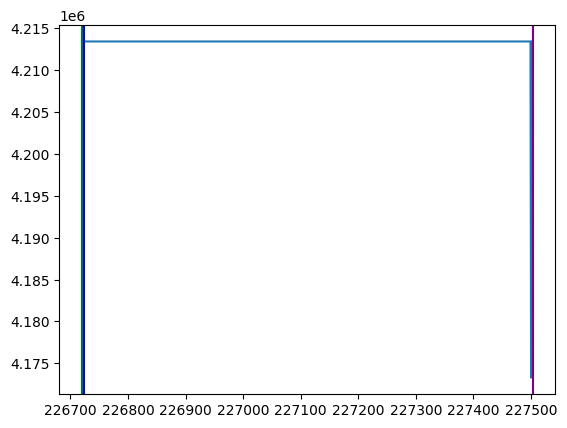

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:57.856204 -> 2025-01-15 11:52:57.857908
2025-01-15 11:52:58.857908
Time taken by inference cycle 246: 0:00:00.001704
Iteration: 246, Power index: 227506 -> 227508
228290


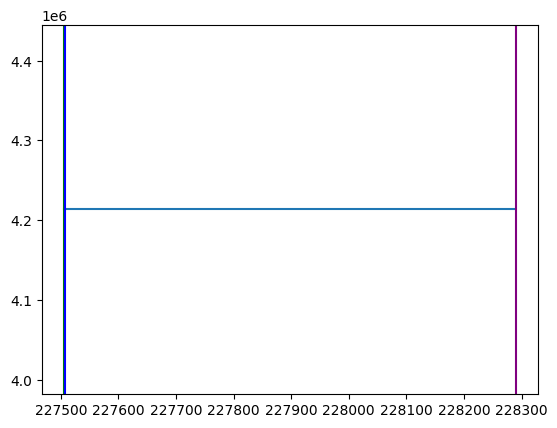

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:58.860836 -> 2025-01-15 11:52:58.862541
2025-01-15 11:52:59.862541
Time taken by inference cycle 247: 0:00:00.001705
Iteration: 247, Power index: 228291 -> 228293
229075


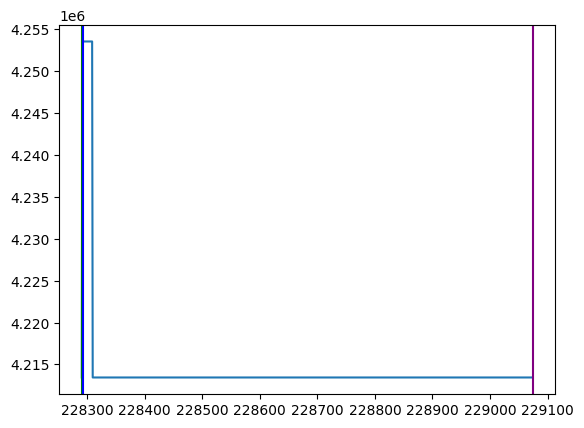

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:52:59.865477 -> 2025-01-15 11:52:59.867191
2025-01-15 11:53:00.867191
Time taken by inference cycle 248: 0:00:00.001714
Iteration: 248, Power index: 229076 -> 229078
229860


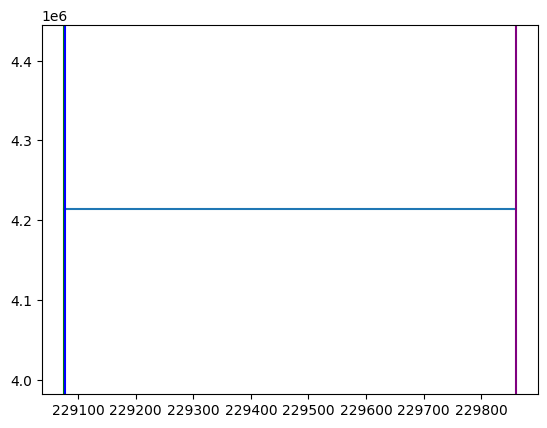

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-15 11:53:00.870103 -> 2025-01-15 11:53:00.871910
2025-01-15 11:53:01.871910
Time taken by inference cycle 249: 0:00:00.001807
Iteration: 249, Power index: 229862 -> 229864
230646


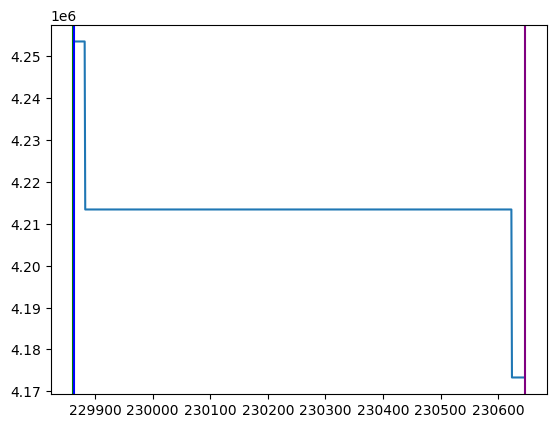

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------


In [113]:
for i in range(200, 250):
    plot_inference_cycle_power(i, resnet34_power_data, resnet34_latency_data)

### Spikes

Similar to resnet18 power profile, there are unusal power spikes pattern where suddenly the inference cycle consumes much greater power than other inference cycles. 

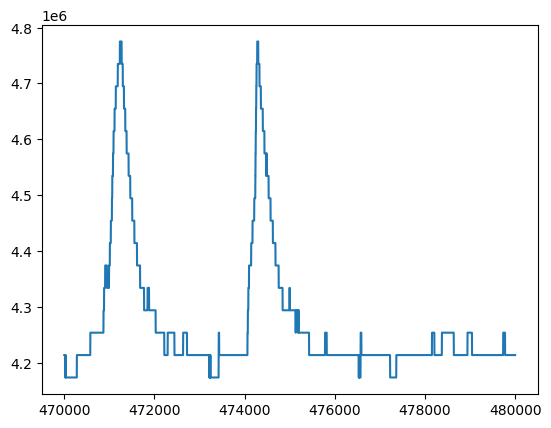

In [138]:
plt.plot(range(470000,480000), [power for (timestamp, power) in resnet34_power_data[470000:480000]])

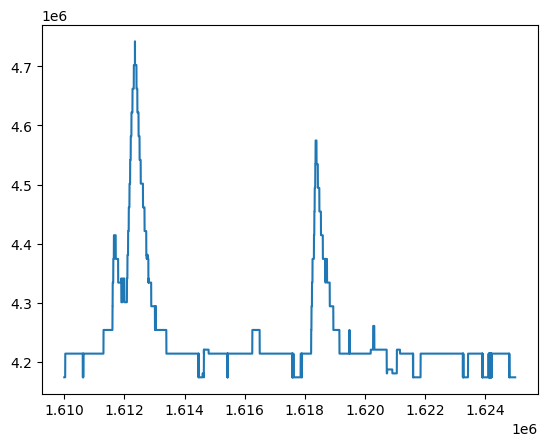

In [147]:
plt.plot(range(1610000, 1625000), [power for (timestamp, power) in resnet18_power_data[1610000:1625000]])

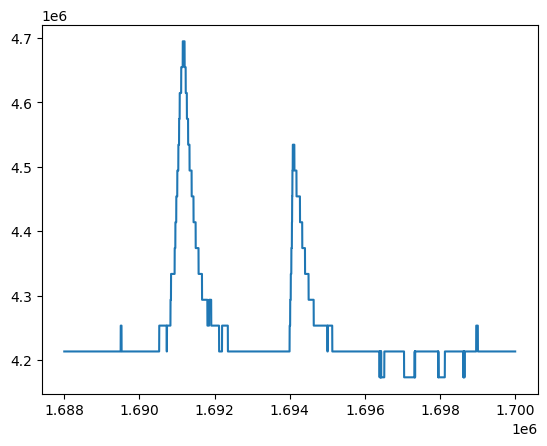

In [148]:
plt.plot(range(1688000, 1700000), [power for (timestamp, power) in resnet18_power_data[1688000:1700000]])

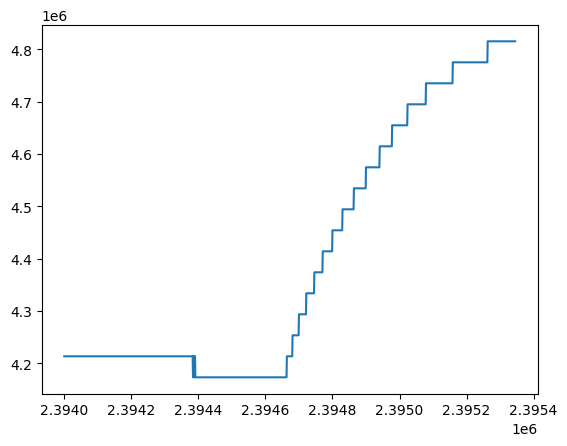

In [155]:
plt.plot(range(2394000, 2395346), [power for (timestamp, power) in resnet34_power_data[2394000:2395346]])

## Questions

Resnet34 provides a different power profile compared to Resnet18. Here we observe that there is an actual increase (*most times*) in power consumed during inference.

The other questions raised in Resnet18 still hold true

- Why are there spikes for handful inference cycles (like an outlier)?
- Why are there spikes during delay sleep interval? 